In [14]:
import os, sys
sys.path.insert(0, r'C:\Users\sp6497_a\FTIR')
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from FTIR_analysis_helpers import MultipassMeas

In [15]:
sample_name          = 'P12-9-25-1-Ge-ATR'
background_samp_name = 'GeATR'
numin, numax = 825, 3100

base_dir = r'C:\Users\sp6497_a\OneDrive - Princeton University\20260416_GeATR\20260416_GeATR\20260422'
bg_dir   = r'C:\Users\sp6497_a\OneDrive - Princeton University\20260416_GeATR\20260416_GeATR'

In [16]:
samp_meas = MultipassMeas(
    TEfile    = os.path.join(base_dir,'P90deg_GeATR_paperalign2_P12-9-25-1.CSV'),
    TMfile    = os.path.join(base_dir, 'P0deg_GeATR_paperalign2_P12-9-25-1.CSV'),
    name      = sample_name,
    nuextrema = [numin, numax],
)

bg_meas = MultipassMeas(
    TEfile    = os.path.join(bg_dir, 'P90deg_GeATR_only.CSV'),
    TMfile    = os.path.join(bg_dir, 'P0deg_GeATR_only.CSV'),
    name      = background_samp_name,
    nuextrema = [numin, numax],
)

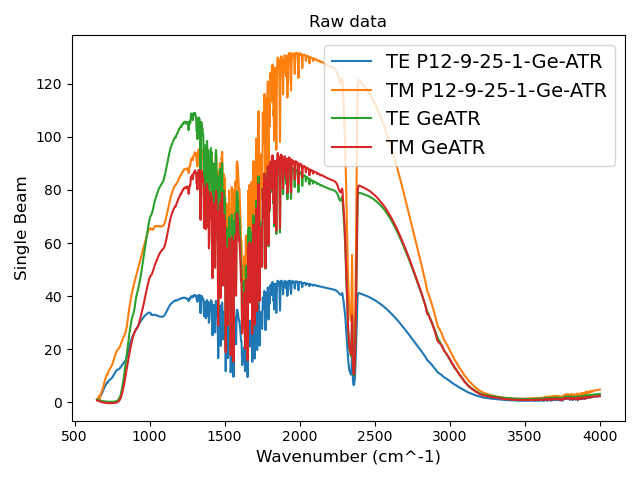

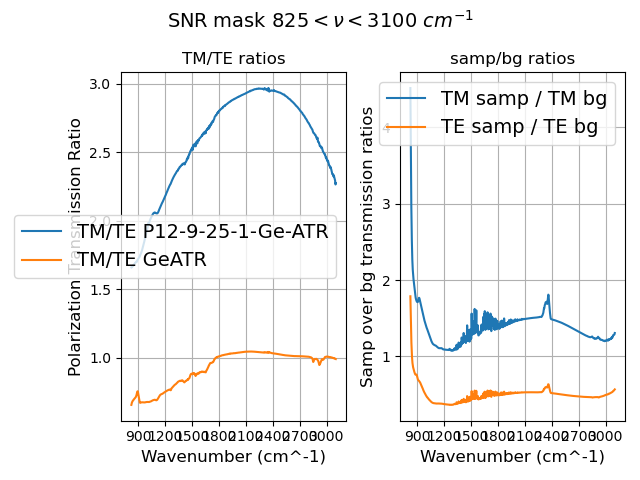

In [17]:
%matplotlib widget
fig_raw, axs_raw = plt.subplots()
# fig_raw.suptitle(sample_name)

axs_raw.set_title('Raw data')
axs_raw.set_xlabel('Wavenumber (cm^-1)', fontsize=12)
axs_raw.set_ylabel('Single Beam', fontsize=12)

samp_meas.plot_single_beam(axs_raw)
bg_meas.plot_single_beam(axs_raw)

axs_raw.legend(prop={'size': 14})

plt.tight_layout()
plt.savefig(os.path.join(base_dir, sample_name + '_raw_scans.jpg'))

fig_ratios, axs_ratios = plt.subplots(1,2)
snr_title = f'SNR mask {numin}' + r'$ < \nu < $' + f'{numax}' + r' ${cm}^{-1}$'

fig_ratios.suptitle(snr_title, fontsize=14)

axs_ratios[0].set_title('TM/TE ratios')
axs_ratios[0].set_xlabel('Wavenumber (cm^-1)', fontsize=12)
axs_ratios[0].set_ylabel('Polarization Transmission Ratio', fontsize=12)


axs_ratios[1].set_title('samp/bg ratios')
axs_ratios[1].set_xlabel('Wavenumber (cm^-1)', fontsize=12)
axs_ratios[1].set_ylabel('Samp over bg transmission ratios', fontsize=12)

for ax in axs_ratios:
    ax.grid()
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

samp_meas.plot_ratio(axs_ratios[0])
bg_meas.plot_ratio(axs_ratios[0])

axs_ratios[1].plot(samp_meas.TM_wavenum_masked, samp_meas.TM_masked / bg_meas.TM_masked, label='TM samp / TM bg')
axs_ratios[1].plot(samp_meas.TE_wavenum_masked, samp_meas.TE_masked / bg_meas.TE_masked, label='TE samp / TE bg')

for ax in axs_ratios:
    ax.legend(prop={'size': 14})
plt.tight_layout()
plt.savefig(os.path.join(base_dir, sample_name + '_ratios.jpg'))


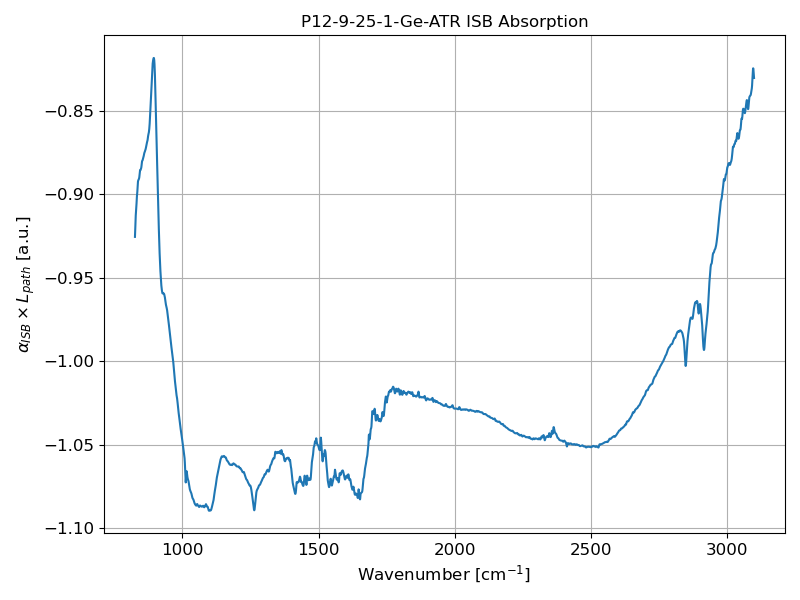

In [22]:
%matplotlib widget

fig_fits, axs_fits = plt.subplots(figsize=(8, 6))

base_title = sample_name + ' ISB Absorption'
base_font_size = 12
title_fontsize = base_font_size
base_lw = 1.5
axs_fits.set_title(base_title, fontsize=title_fontsize)
axs_fits.set_xlabel(r'Wavenumber [$\text{cm}^{-1}$]', fontsize=base_font_size)
axs_fits.set_ylabel(r'$\alpha_{ISB} \times L_{path}$ [a.u.]', fontsize=base_font_size)
axs_fits.tick_params(axis='both', which='major', labelsize=base_font_size)
axs_fits.grid()
# axs_fits.xaxis.set_major_locator(MaxNLocator(integer=True))
labelalt = (
    rf"$-\ln \left(\frac{{I_{{TM}}}}{{I_{{TE}}}}\right)"
    rf"+ \ln \left(\frac{{I_{{{'substrate'},TM}}}}{{I_{{{'substrate'},TE}}}}\right)$"
)
samp_meas.plot_alpha_ISB(bg_meas, axs_fits,lw=base_lw,add_label=False)

# Single Lorentzian fit

# result_both = fit_nlorentz(
#     nu_range      = [948, 1594],
#     nu0_guesses   = [1086, 1300],
#     kappa_guesses = [50, 100],
#     wavenum       = wavenum,
#     alpha_ISB     = alpha_ISB,
# )

# result = samp_meas.fit_nlorentz(
#     nu_range    = [948, 1594],
#     nu0_guesses   = [1086,1300],
#     kappa_guesses = [50,100],
#     background  = bg_meas,
# )
# samp_meas.plot_fit(result, axs_fits,lw=base_lw,component_colors=['brown','salmon'],combined_color='gray')

# axs_fits.legend(prop={'size': base_font_size})
# # axs_fits.
plt.tight_layout()
plt.savefig(os.path.join(base_dir, sample_name + '_alpha_ISB.jpg'))
# # plt.show()